<a href="https://colab.research.google.com/github/VedantPaste1705/CSL701_CS40_Machine-Learning-Lab/blob/main/Experiments/ML40_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

Name : Vedant Vinay Paste

Roll No : CS-40

Batch : CS-03

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


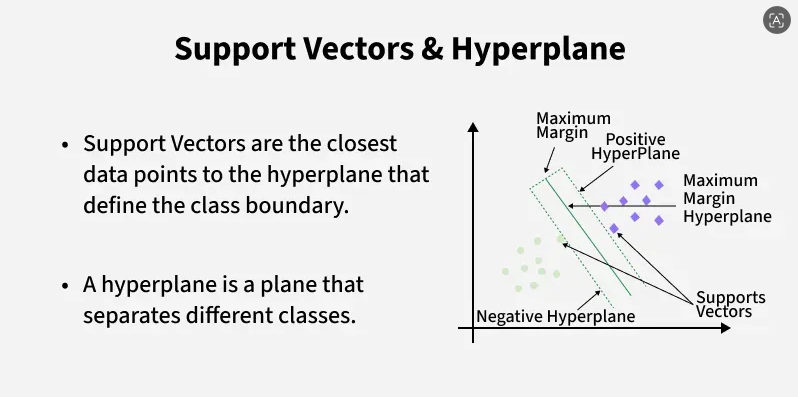
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Iris.csv")

print(df.head())

Saving Iris.csv to Iris (1).csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


# Task 2: Explore the Dataset

In [15]:
print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())

print("\nTarget classes:")
print(df["Species"].unique())

Shape of dataset:
(150, 6)

Column names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical summary:
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.0

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [16]:
# Remove Id column
df = df.drop("Id", axis=1)

# Select features
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Select target
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [17]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardize the data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [18]:
# Create Linear SVM model
svm_model = SVC(kernel="linear")

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


SVM Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


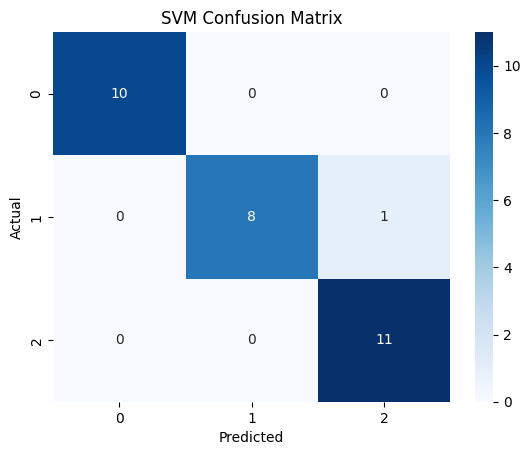


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.89      0.94         9
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [19]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm)

# Display confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

   PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2
SVM model trained successfully.


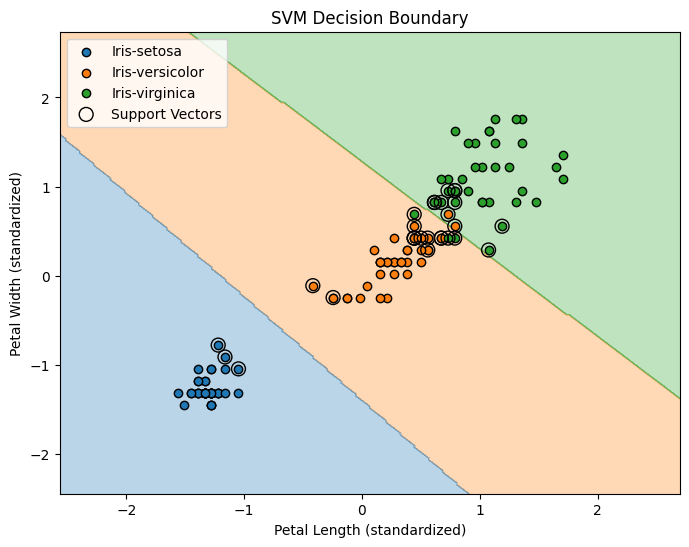

Number of Support Vectors: 29


In [20]:
# Select two features
X2 = df[["PetalLengthCm", "PetalWidthCm"]]
y2 = df["Species"]

print(X2.head())


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

# Scale the data
scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)


# Create Linear SVM
svm2 = SVC(kernel="linear")

# Train
svm2.fit(X2_train, y2_train)

print("SVM model trained successfully.")

# Create a grid covering the whole plot area
x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict for every grid point and convert class names to numbers
Z = svm2.predict(np.c_[xx.ravel(), yy.ravel()])
classes = list(y2.unique())
class_to_number = {c: i for i, c in enumerate(classes)}
Z = np.array([class_to_number[c] for c in Z]).reshape(xx.shape)

# ONE colour list used for BOTH the regions and the points, so they match
from matplotlib.colors import ListedColormap
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
cmap = ListedColormap(colors)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

for i, species in enumerate(classes):
    mask = y2_train.values == species
    plt.scatter(X2_train[mask, 0], X2_train[mask, 1],
                color=colors[i], edgecolor="k", label=species)

# Support vectors (circled)
plt.scatter(svm2.support_vectors_[:, 0], svm2.support_vectors_[:, 1],
            s=100, facecolors="none", edgecolors="black", label="Support Vectors")

plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.title("SVM Decision Boundary")
plt.legend()
plt.show()

print("Number of Support Vectors:", len(svm2.support_vectors_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Predictions:
['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa'
 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-setosa' 'Iris-setosa']


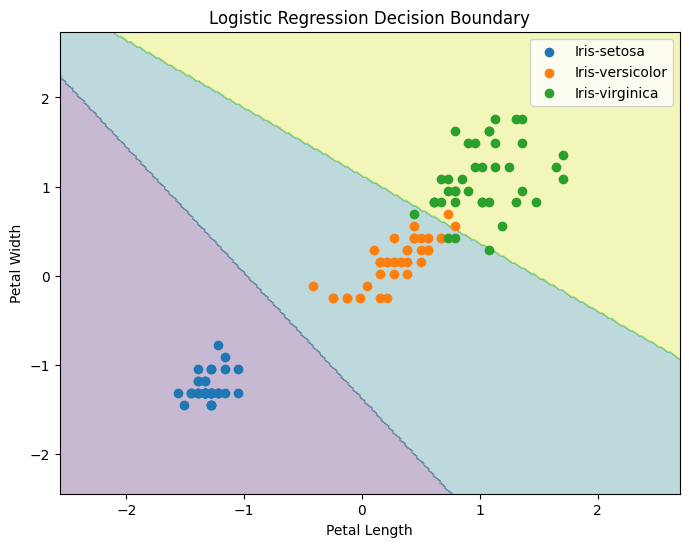

In [21]:
# Create Logistic Regression model
log_model = LogisticRegression()

# Train model
log_model.fit(X2_train, y2_train)

# Make predictions
y_pred_log = log_model.predict(X2_test)

print("Logistic Regression Predictions:")
print(y_pred_log)


# Predict grid points
Z_log = log_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

# Convert class names to numbers
Z_log = np.array([class_to_number[c] for c in Z_log])
Z_log = Z_log.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))

plt.contourf(
    xx, yy, Z_log,
    alpha=0.3
)

for species in classes:
    mask = y2_train.values == species

    plt.scatter(
        X2_train[mask, 0],
        X2_train[mask, 1],
        label=species
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

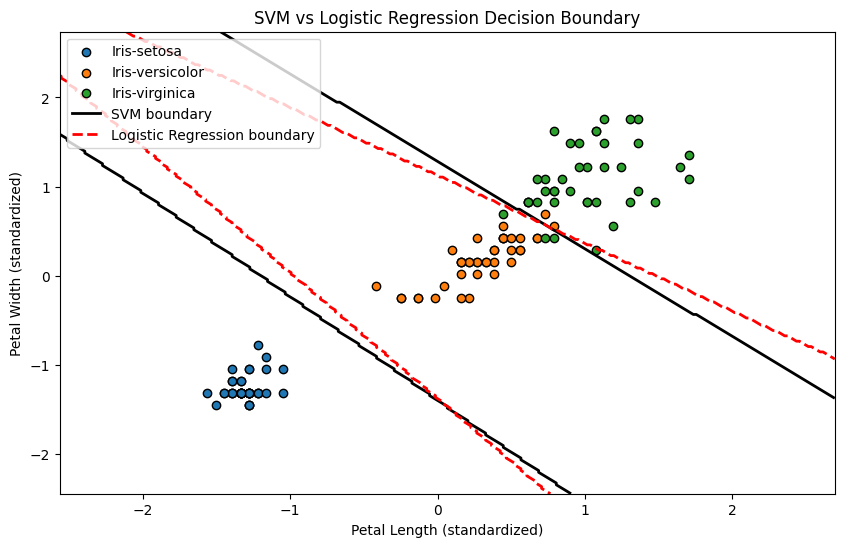

In [22]:
from matplotlib.lines import Line2D

# Grid predictions from both models
Z_svm = svm2.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = np.array([class_to_number[c] for c in Z_svm]).reshape(xx.shape)

Z_log = log_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_log = np.array([class_to_number[c] for c in Z_log]).reshape(xx.shape)

plt.figure(figsize=(10, 6))

# Data points first (same colours as before)
for i, species in enumerate(classes):
    mask = y2_train.values == species
    plt.scatter(X2_train[mask, 0], X2_train[mask, 1],
                color=colors[i], edgecolor="k", label=species)

# SVM boundary = solid black, Logistic Regression boundary = dashed red
plt.contour(xx, yy, Z_svm, levels=[0.5, 1.5], colors="black", linewidths=2)
plt.contour(xx, yy, Z_log, levels=[0.5, 1.5], colors="red",
            linestyles="dashed", linewidths=2)

# Legend: points + proxy entries for the two kinds of line
handles, labels = plt.gca().get_legend_handles_labels()
handles += [Line2D([0], [0], color="black", lw=2),
            Line2D([0], [0], color="red", lw=2, ls="--")]
labels += ["SVM boundary", "Logistic Regression boundary"]
plt.legend(handles, labels)

plt.xlabel("Petal Length (standardized)")
plt.ylabel("Petal Width (standardized)")
plt.title("SVM vs Logistic Regression Decision Boundary")
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [23]:
#Accuracy
# SVM predictions
svm_pred = svm2.predict(X2_test)

# Logistic Regression predictions
log_pred = log_model.predict(X2_test)

# Accuracy
svm_accuracy = accuracy_score(y2_test, svm_pred)
log_accuracy = accuracy_score(y2_test, log_pred)

print("SVM Accuracy:", svm_accuracy)
print("Logistic Regression Accuracy:", log_accuracy)


#SVM confusion matrix
print("SVM Confusion Matrix:")
print(confusion_matrix(y2_test, svm_pred))

print("\nSVM Classification Report:")
print(classification_report(y2_test, svm_pred))

#Logistic regression and confusion matrix
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y2_test, log_pred))

print("\nLogistic Regression Classification Report:")
print(classification_report(y2_test, log_pred))

SVM Accuracy: 1.0
Logistic Regression Accuracy: 1.0
SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00       

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.